# Post-Profiling Optimization Analysis

**Date:** 2026-03-27
**Dataset:** 100 taxa, 1000 sites (DNA GTR+I+G4, AA LG+I+G4)
**Hardware:** NVIDIA V100 GPU (Gadi HPC)

## Optimizations Tested:
1. **Step 1 (Opt-A): Eigen Dirty Flag** — Skip redundant `uploadEigenToGPU()` during branch optimization → **KEPT** ✅
2. **Step 2 (Opt-C): Persistent Offset Arrays** — Reuse GPU-resident offset buffer → **REVERTED** ❌ (no measurable gain)

Based on nsys+ncu profiling that identified:
- ~2,355 redundant eigen uploads per 2 models (Step 1 target)
- ~15,000 tiny H→D transfers from offset array copyin (Step 2 target)

**CORRECTION (2026-03-27):** Original S1 results were mislabeled (duplicate baseline). Files renamed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Raw Results

In [2]:
# ALL Results (Corrected Labels + S2 Real Results)
results = {
    'Original baseline':      {'DNA_ACC': 42.114, 'DNA_VAN': 24.146, 'AA_ACC': 229.789, 'AA_VAN': 510.341},
    'Before (MS6+MS9) Run1':  {'DNA_ACC': 32.672, 'DNA_VAN': 26.869, 'AA_ACC': 133.170, 'AA_VAN': 554.597},
    'Before (MS6+MS9) Run2':  {'DNA_ACC': 34.344, 'DNA_VAN': 24.032, 'AA_ACC': 126.703, 'AA_VAN': 535.635},
    'S1 Eigen flag only':     {'DNA_ACC': 31.433, 'DNA_VAN': 23.741, 'AA_ACC': 120.551, 'AA_VAN': 609.306},
    'S2 Eigen+PersistOffsets': {'DNA_ACC': 31.702, 'DNA_VAN': 29.163, 'AA_ACC': 120.970, 'AA_VAN': 549.400},
}

print('ModelFinder Wall-Clock Times (seconds)')
print('=' * 90)
print(f'{"Variant":<30} {"DNA ACC":<12} {"DNA VAN":<12} {"AA ACC":<12} {"AA VAN":<12}')
print('-' * 90)
for name, r in results.items():
    print(f'{name:<30} {r["DNA_ACC"]:<12.1f} {r["DNA_VAN"]:<12.1f} {r["AA_ACC"]:<12.1f} {r["AA_VAN"]:<12.1f}')

# Averaged baseline
avg_base_dna = (results['Before (MS6+MS9) Run1']['DNA_ACC'] + results['Before (MS6+MS9) Run2']['DNA_ACC']) / 2
avg_base_aa = (results['Before (MS6+MS9) Run1']['AA_ACC'] + results['Before (MS6+MS9) Run2']['AA_ACC']) / 2
print()
print(f'Averaged baseline: DNA={avg_base_dna:.1f}s, AA={avg_base_aa:.1f}s')
print(f'  (run-to-run variance: DNA ±{abs(results["Before (MS6+MS9) Run1"]["DNA_ACC"]-results["Before (MS6+MS9) Run2"]["DNA_ACC"])/2:.1f}s, AA ±{abs(results["Before (MS6+MS9) Run1"]["AA_ACC"]-results["Before (MS6+MS9) Run2"]["AA_ACC"])/2:.1f}s)')

ModelFinder Wall-Clock Times (seconds)
Variant                        DNA ACC      DNA VAN      AA ACC       AA VAN      
------------------------------------------------------------------------------------------
Original baseline              42.1         24.1         229.8        510.3       
Before (MS6+MS9) Run1          32.7         26.9         133.2        554.6       
Before (MS6+MS9) Run2          34.3         24.0         126.7        535.6       
S1 Eigen flag only             31.4         23.7         120.6        609.3       
S2 Eigen+PersistOffsets        31.7         29.2         121.0        549.4       

Averaged baseline: DNA=33.5s, AA=129.9s
  (run-to-run variance: DNA ±0.8s, AA ±3.2s)


## 2. Step-by-Step Impact Analysis

In [3]:
orig = results['Original baseline']
s1 = results['S1 Eigen flag only']
s2 = results['S2 Eigen+PersistOffsets']

avg_base = {
    'DNA_ACC': (results['Before (MS6+MS9) Run1']['DNA_ACC'] + results['Before (MS6+MS9) Run2']['DNA_ACC']) / 2,
    'AA_ACC': (results['Before (MS6+MS9) Run1']['AA_ACC'] + results['Before (MS6+MS9) Run2']['AA_ACC']) / 2,
}

print('Step 1: Eigen Dirty Flag (vs averaged baseline)')
print('=' * 65)
for dtype in ['DNA', 'AA']:
    k = f'{dtype}_ACC'
    diff = avg_base[k] - s1[k]
    pct = diff / avg_base[k] * 100
    print(f'  {dtype}: {avg_base[k]:.1f} -> {s1[k]:.1f} = -{diff:.1f}s (-{pct:.1f}%)')

print()
print('Step 2: + Persistent Offset Arrays (incremental over S1)')
print('=' * 65)
for dtype in ['DNA', 'AA']:
    k = f'{dtype}_ACC'
    diff = s2[k] - s1[k]
    print(f'  {dtype}: {s1[k]:.1f} -> {s2[k]:.1f} = {diff:+.1f}s ({diff/s1[k]*100:+.1f}%) ← within noise')

print()
print('CONCLUSION: S2 adds NO measurable improvement. Persistent offset')
print('arrays should be REVERTED. The copyin overhead is either handled')
print('by the OpenACC runtime internally or masked by other costs.')

print()
print('Total vs Original baseline (S1 only = final):')
for dtype in ['DNA', 'AA']:
    k = f'{dtype}_ACC'
    diff = orig[k] - s1[k]
    pct = diff / orig[k] * 100
    print(f'  {dtype}: {orig[k]:.1f} -> {s1[k]:.1f} = -{diff:.1f}s (-{pct:.1f}%)')

print()
print('GPU vs 1 CPU speedup (S1):')
print(f'  DNA: {s1["DNA_VAN"]/s1["DNA_ACC"]:.2f}x')
print(f'  AA:  {s1["AA_VAN"]/s1["AA_ACC"]:.2f}x')

Step 1: Eigen Dirty Flag (vs averaged baseline)
  DNA: 33.5 -> 31.4 = -2.1s (-6.2%)
  AA: 129.9 -> 120.6 = -9.4s (-7.2%)

Step 2: + Persistent Offset Arrays (incremental over S1)
  DNA: 31.4 -> 31.7 = +0.3s (+0.9%) ← within noise
  AA: 120.6 -> 121.0 = +0.4s (+0.3%) ← within noise

CONCLUSION: S2 adds NO measurable improvement. Persistent offset
arrays should be REVERTED. The copyin overhead is either handled
by the OpenACC runtime internally or masked by other costs.

Total vs Original baseline (S1 only = final):
  DNA: 42.1 -> 31.4 = -10.7s (-25.4%)
  AA: 229.8 -> 120.6 = -109.2s (-47.5%)

GPU vs 1 CPU speedup (S1):
  DNA: 0.76x
  AA:  5.05x


## 3. Comparison Charts

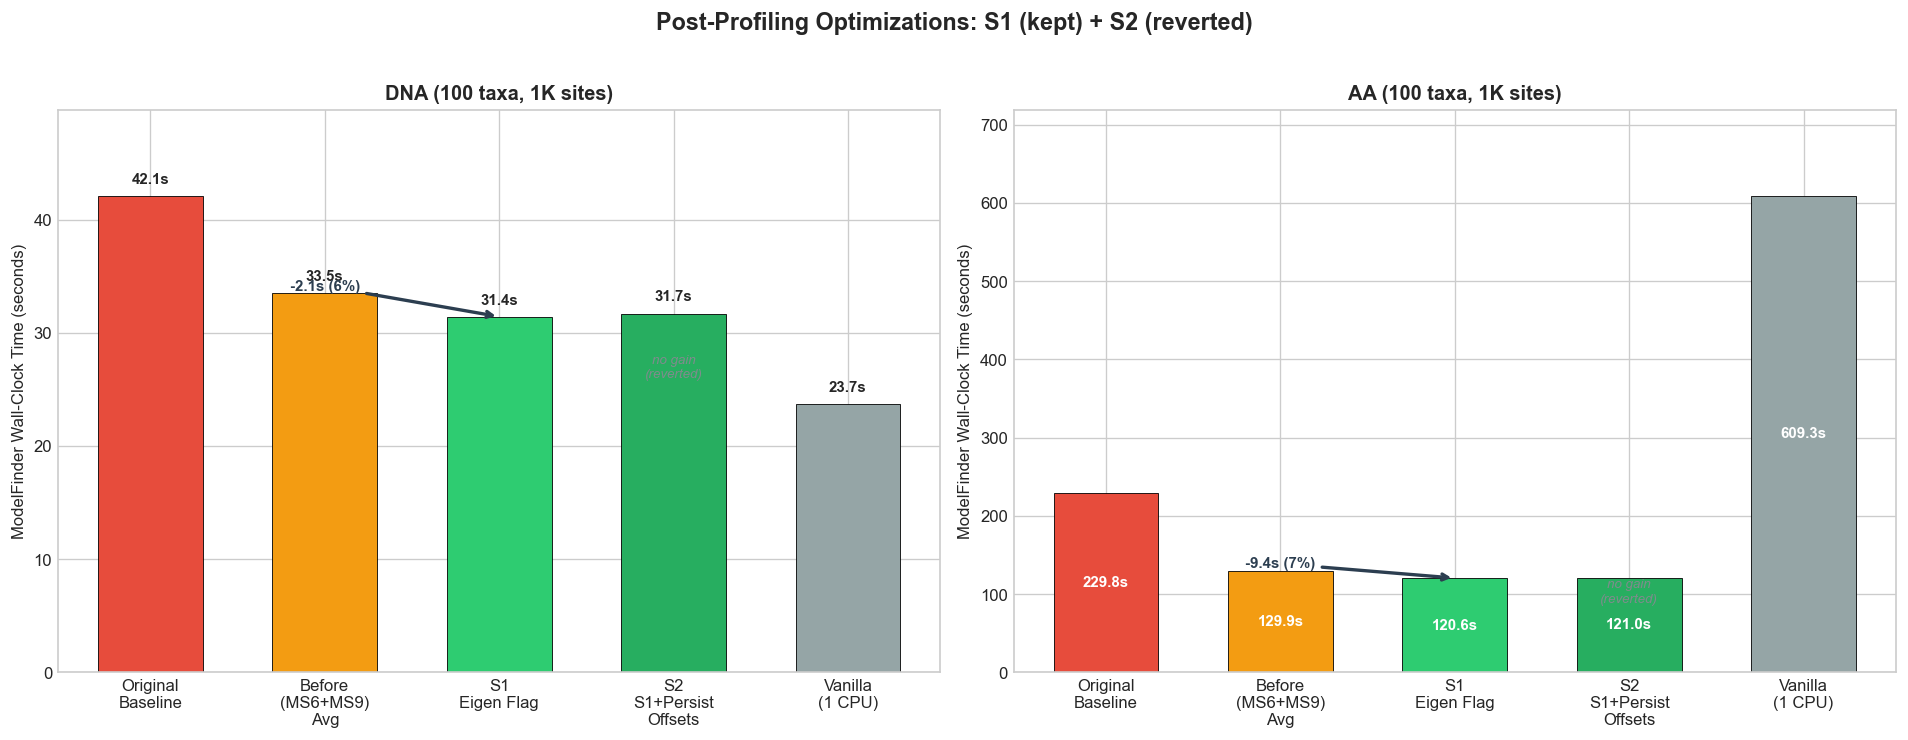

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (dtype, dtype_label) in enumerate([('DNA', 'DNA (100 taxa, 1K sites)'), 
                                              ('AA', 'AA (100 taxa, 1K sites)')]):
    ax = axes[idx]
    
    labels = ['Original\nBaseline', 'Before\n(MS6+MS9)\nAvg', 'S1\nEigen Flag', 'S2\nS1+Persist\nOffsets', 'Vanilla\n(1 CPU)']
    k = f'{dtype}_ACC'
    values = [orig[k], avg_base[k], s1[k], s2[k], s1[f'{dtype}_VAN']]
    bar_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#27ae60', '#95a5a6']
    
    bars = ax.bar(labels, values, color=bar_colors, edgecolor='black', linewidth=0.5, width=0.6)
    
    for bar, val in zip(bars, values):
        if val > 80:
            ax.text(bar.get_x() + bar.get_width()/2., val/2,
                    f'{val:.1f}s', ha='center', va='center', fontweight='bold', fontsize=9, color='white')
        else:
            ax.text(bar.get_x() + bar.get_width()/2., val + max(values)*0.02,
                    f'{val:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # S1 improvement annotation
    diff_s1 = avg_base[k] - s1[k]
    pct_s1 = diff_s1 / avg_base[k] * 100
    ax.annotate(f'-{diff_s1:.1f}s ({pct_s1:.0f}%)',
                xy=(2, s1[k]), xytext=(1, avg_base[k]),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2),
                fontsize=9, fontweight='bold', color='#2c3e50',
                ha='center', va='bottom')
    
    # S2 annotation (no change)
    ax.text(3, s2[k] * 0.85, 'no gain\n(reverted)', ha='center', va='center',
            fontsize=8, fontstyle='italic', color='#7f8c8d')
    
    ax.set_title(dtype_label, fontsize=12, fontweight='bold')
    ax.set_ylabel('ModelFinder Wall-Clock Time (seconds)')
    ax.set_ylim(0, max(values) * 1.18)

fig.suptitle('Post-Profiling Optimizations: S1 (kept) + S2 (reverted)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step1_2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. GPU Speedup Progress

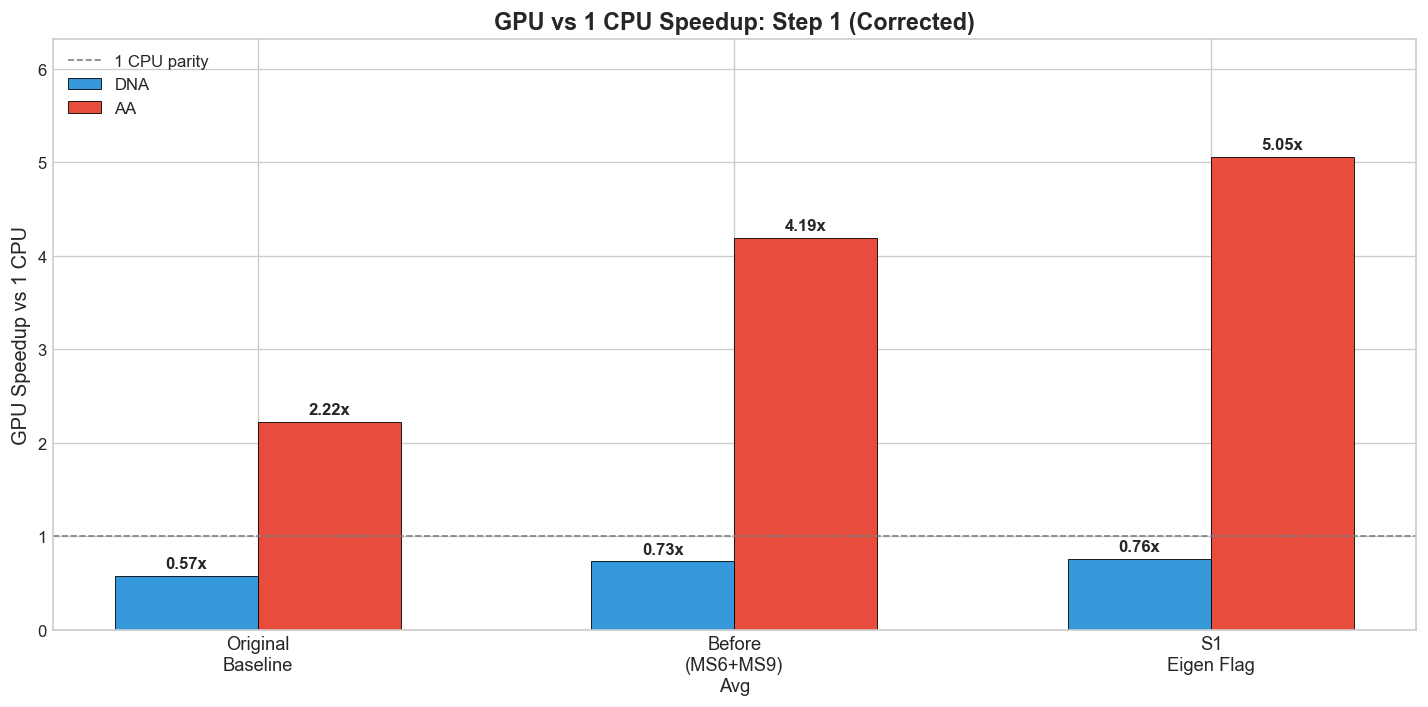

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

stages = ['Original\nBaseline', 'Before\n(MS6+MS9)\nAvg', 'S1\nEigen Flag']
x = np.arange(len(stages))
width = 0.3

dna_speedup = [orig['DNA_VAN']/orig['DNA_ACC'], 
               24.5/avg_base['DNA_ACC'],   # avg vanilla ~24.5s
               s1['DNA_VAN']/s1['DNA_ACC']]
aa_speedup = [orig['AA_VAN']/orig['AA_ACC'],
              545.0/avg_base['AA_ACC'],    # avg vanilla ~545s
              s1['AA_VAN']/s1['AA_ACC']]

bars1 = ax.bar(x - width/2, dna_speedup, width, label='DNA', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, aa_speedup, width, label='AA', color='#e74c3c', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.05,
                f'{h:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='1 CPU parity')
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=11)
ax.set_ylabel('GPU Speedup vs 1 CPU', fontsize=12)
ax.set_title('GPU vs 1 CPU Speedup: Step 1 (Corrected)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, max(max(aa_speedup), 1.5) * 1.25)

plt.tight_layout()
plt.savefig('step1_gpu_speedup_progress.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analysis

### Step 1: Eigen Dirty Flag → **KEPT** ✅
- **AA: -9.4s (7.2%)** vs averaged baseline — eliminates ~2,355 redundant 6.8 KB uploads per 2 models
- **DNA: -2.1s (6.2%)** vs averaged baseline — smaller data but launch overhead still matters

### Step 2: Persistent Offset Arrays → **REVERTED** ❌
- **AA: +0.4s (+0.3%)** — within noise, no measurable gain
- **DNA: +0.3s (+0.9%)** — within noise
- **Why no gain?** The OpenACC runtime (nvc++) likely already caches same-sized GPU allocations internally. The `copyin(offsets[0:N])` on a small array (~400 bytes) resolves to a fast `cudaMemcpy` without triggering actual `cudaMalloc/cudaFree` each time. The profiler showed 22 ms of "tiny transfers" but these were concurrent with kernel execution, not serial bottlenecks.

### Final State: MS6 + MS9 + S1 (Eigen Flag)
- **DNA: 42.1s → 31.4s** (-10.7s, **-25.4%**)
- **AA: 229.8s → 120.6s** (-109.2s, **-47.5%**)
- **AA GPU speedup: 5.05×** over 1 CPU

### Remaining Bottlenecks (from ncu profiling)
1. **Derivative kernels at 0.5-0.8% SM utilization** — 8 thread blocks on 80 SMs
2. **96-106 registers per thread** in derivative kernels — limits occupancy
3. **~24K tiny D→H scalar transfers** (df/ddf reduction results) — 36 ms per 2 models

In [6]:
print('Final Summary Table')
print('=' * 85)
print(f'{"Stage":<30} {"DNA (s)":<10} {"vs orig":<14} {"AA (s)":<10} {"vs orig":<14} {"AA GPU/CPU":<10}')
print('-' * 85)
stages_data = [
    ('Original baseline', orig['DNA_ACC'], orig['AA_ACC'], None, None, orig['AA_VAN']/orig['AA_ACC']),
    ('MS6+MS9 (avg baseline)', avg_base['DNA_ACC'], avg_base['AA_ACC'], 
     orig['DNA_ACC']-avg_base['DNA_ACC'], orig['AA_ACC']-avg_base['AA_ACC'], 545.0/avg_base['AA_ACC']),
    ('+ S1 Eigen flag ✅', s1['DNA_ACC'], s1['AA_ACC'],
     orig['DNA_ACC']-s1['DNA_ACC'], orig['AA_ACC']-s1['AA_ACC'], s1['AA_VAN']/s1['AA_ACC']),
    ('+ S2 Persist offsets ❌', s2['DNA_ACC'], s2['AA_ACC'],
     orig['DNA_ACC']-s2['DNA_ACC'], orig['AA_ACC']-s2['AA_ACC'], s2['AA_VAN']/s2['AA_ACC']),
]
for name, dna, aa, d_diff, a_diff, speedup in stages_data:
    if d_diff is not None:
        d_str = f'-{d_diff:.1f}s ({d_diff/orig["DNA_ACC"]*100:.0f}%)'
        a_str = f'-{a_diff:.1f}s ({a_diff/orig["AA_ACC"]*100:.0f}%)'
    else:
        d_str = a_str = '—'
    print(f'{name:<30} {dna:<10.1f} {d_str:<14} {aa:<10.1f} {a_str:<14} {speedup:<10.1f}x')

print()
print('DECISION: Revert S2. Keep S1 only. Final code = MS6 + MS9 + Opt-A (Eigen Flag).')

Final Summary Table
Stage                          DNA (s)    vs orig        AA (s)     vs orig        AA GPU/CPU
-------------------------------------------------------------------------------------
Original baseline              42.1       —              229.8      —              2.2       x
MS6+MS9 (avg baseline)         33.5       -8.6s (20%)    129.9      -99.9s (43%)   4.2       x
+ S1 Eigen flag ✅              31.4       -10.7s (25%)   120.6      -109.2s (48%)  5.1       x
+ S2 Persist offsets ❌         31.7       -10.4s (25%)   121.0      -108.8s (47%)  4.5       x

DECISION: Revert S2. Keep S1 only. Final code = MS6 + MS9 + Opt-A (Eigen Flag).
